# Ligand-Receptor plotting

In [1]:
import squidpy as sq
import numpy as np
import pandas as pd
from anndata import AnnData
from typing import Mapping, Sequence
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from graph_transformer_long_range_niches.pl.ligand_receptor import ligand_receptor_interaction

Load pre-processed squidpy dataset

In [2]:
# load the pre-processed dataset
adata = sq.datasets.merfish()
adata

AnnData object with n_obs × n_vars = 73655 × 161
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch'
    uns: 'Cell_class_colors'
    obsm: 'spatial', 'spatial3d'

In [3]:
subadata = adata[adata.obs.Bregma == -9]

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


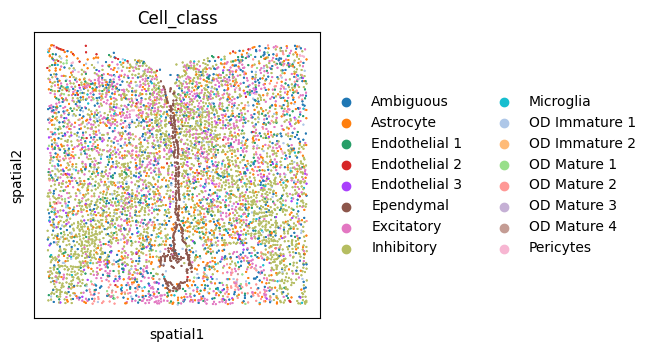

In [4]:
sq.pl.spatial_scatter(
  subadata  , shape=None, color="Cell_class", size=1
)

Ligand-Receptor squidpy analysis to find interacting LR pairs.

In [5]:
res = sq.gr.ligrec(
    subadata,
    n_perms=1000,
    cluster_key="Cell_class",
    copy=True,
    use_raw=False,
    transmitter_params={"categories": "ligand"},
    receiver_params={"categories": "receptor"},
)

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  File "/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/urllib3/connectionpool.py", line 404, in _make_request
    self._validate_conn(conn)
  File "/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/urllib3/connectionpool.py", line 1060, in _validate_conn
    conn.connect()
  File "/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/urllib3/connection.py", line 419, in connect
    self.sock = ssl_wrap_socket(
                ^^^^^^^^^^^^^^^^
  File "/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/env

In [6]:
res["means"].head()

cluster_1     Ambiguous                                                      \
cluster_2     Ambiguous Astrocyte Endothelial 1 Endothelial 2 Endothelial 3   
source target                                                                 
CCK    CCKBR   0.328673  0.129803       0.11499       0.10844      0.167904   
CRH    CRHR1   0.330943  0.135669      0.102548      0.103251      0.095919   
       CRHR2   0.169217  0.057456      0.087599       0.11273      0.114682   
UCN3   CRHR2   0.168458  0.056697       0.08684       0.11197      0.113923   
PENK   OPRD1   0.618841   0.19278      0.180996      0.147629      0.263203   

cluster_1                                                              ...  \
cluster_2     Ependymal Excitatory Inhibitory Microglia OD Immature 1  ...   
source target                                                          ...   
CCK    CCKBR   3.492219   0.640666   0.407462  0.171014      0.228355  ...   
CRH    CRHR1   0.085575   0.325875   0.525499  0.132429      0.213631  ...   
       CRHR2     0.0769   0.319316   0.209749  0.058387      0.093995  ...   
UCN3   CRHR2   0.076141   0.318557    0.20899  0.057627      0.093236  ...   
PENK   OPRD1   0.177052   0.422948   0.697729   0.26276      0.358137  ...   

cluster_1      Pericytes                                                   \
cluster_2     Excitatory Inhibitory Microglia OD Immature 1 OD Immature 2   
source target                                                               
CCK    CCKBR    0.637581   0.404378   0.16793      0.225271      1.991701   
CRH    CRHR1    0.322135    0.52176   0.12869      0.209892      0.444345   
       CRHR2    0.315577    0.20601  0.054647      0.090255             0   
UCN3   CRHR2      0.3163   0.206733   0.05537      0.090979             0   
PENK   OPRD1    0.389515   0.664296  0.229328      0.324704      0.248829   

cluster_1                                                                
cluster_2     OD Mature 1 OD Mature 2 OD Mature 3 OD Mature 4 Pericytes  
source target                                                            
CCK    CCKBR     0.105735    0.141991    0.240101    0.112945  0.222412  
CRH    CRHR1     0.068997    0.106763           0           0  0.189138  
       CRHR2     0.017338    0.048731           0    0.110323  0.132343  
UCN3   CRHR2     0.018061    0.049454           0    0.111046  0.133067  
PENK   OPRD1     0.096002    0.082657           0    0.062896  0.148498  

[5 rows x 256 columns]

11


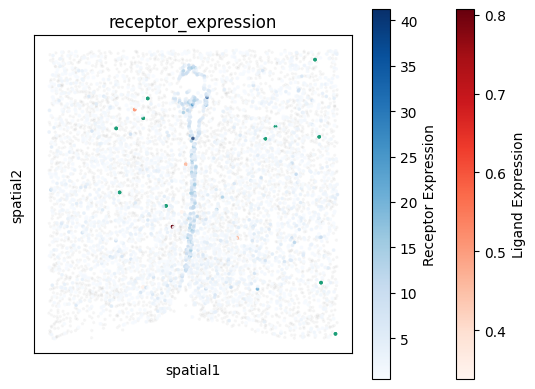

In [81]:
ligand="CCK"
receptor="CCKBR"

ligand_receptor_interaction(subadata, ligand, receptor, receptor_threshold = 0.5)